In [1]:
import pandas as pd
import pyterrier as pt
if not pt.started():
    pt.init()
import matplotlib.pyplot as plt
from tqdm import tqdm

PyTerrier 0.10.0 has loaded Terrier 5.11 (built by craig.macdonald on 2025-01-13 21:29) and terrier-helper 0.0.8



In [2]:
ohsumed_docs = pd.read_pickle("/nfs/primary/sas_reranker/ohsumed_docs_w_t5base_sensitivity.pkl")
queries = pd.read_pickle("/nfs/primary/graph_adaptive_reranking/queries.pkl")
qrels = pd.read_pickle("/nfs/primary/graph_adaptive_reranking/qrels.pkl")

In [10]:
bm25 = pt.io.read_results("./runs/intermediates/bm25 % 1000")
bm25 = bm25[bm25["qid"] == "1"]

In [11]:
bm25_monot5_relevance = pt.io.read_results("./runs/bm25 % 1000 >> filter % 100 >> get_text >> monot5_relevance")
bm25_monot5_relevance = bm25_monot5_relevance[bm25_monot5_relevance["qid"] == "1"]

In [14]:
bm25 = pd.merge(bm25, qrels, on = ["qid", "docno"], how = "left").fillna(0)
bm25_monot5_relevance = pd.merge(bm25_monot5_relevance, qrels, on = ["qid", "docno"], how = "left").fillna(0)
bm25 = pd.merge(bm25, ohsumed_docs, on = "docno")
bm25_monot5_relevance = pd.merge(bm25_monot5_relevance, ohsumed_docs, on = "docno")

In [15]:
merged = pd.merge(bm25[['qid', 'docno', 'rank']], bm25_monot5_relevance[['qid', 'docno', 'rank']], 
                  on=['qid', 'docno'], 
                  suffixes=('_1', '_2'))

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

# Merge both results on qid and docno
# merged = pd.merge(
#     bm25[['qid', 'docno', 'rank', 'label', 'sensitivity']],
#     bm25_monot5_relevance[['qid', 'docno', 'rank']],
#     on=['qid', 'docno'],
#     suffixes=('_1', '_2')
# )
# merged

merged = pd.merge(bm25[['qid', 'docno', 'rank', 'label', 'sensitivity']],
                  bm25_monot5_relevance[['qid', 'docno', 'rank']], 
                  on=['qid', 'docno'], how='outer', suffixes=('_1', '_2'))
merged['label'] = merged['label'].fillna(0)
# merged['sensitivity'] = merged['sensitivity'].fillna(1)
merged

,qid,docno,rank_1,label,sensitivity,rank_2
0,1,40626,0,2.0,0,7.0
1,1,244338,1,0.0,0,34.0
2,1,165240,2,2.0,0,16.0
3,1,48192,3,1.0,0,6.0
4,1,256570,4,2.0,1,4.0
...,...,...,...,...,...,...
995,1,122481,995,0.0,0,NaN
996,1,292739,996,0.0,0,NaN
997,1,314425,997,0.0,0,NaN
998,1,328255,998,0.0,0,NaN


plotting: 100%|██████████| 1000/1000 [00:06<00:00, 148.99it/s]


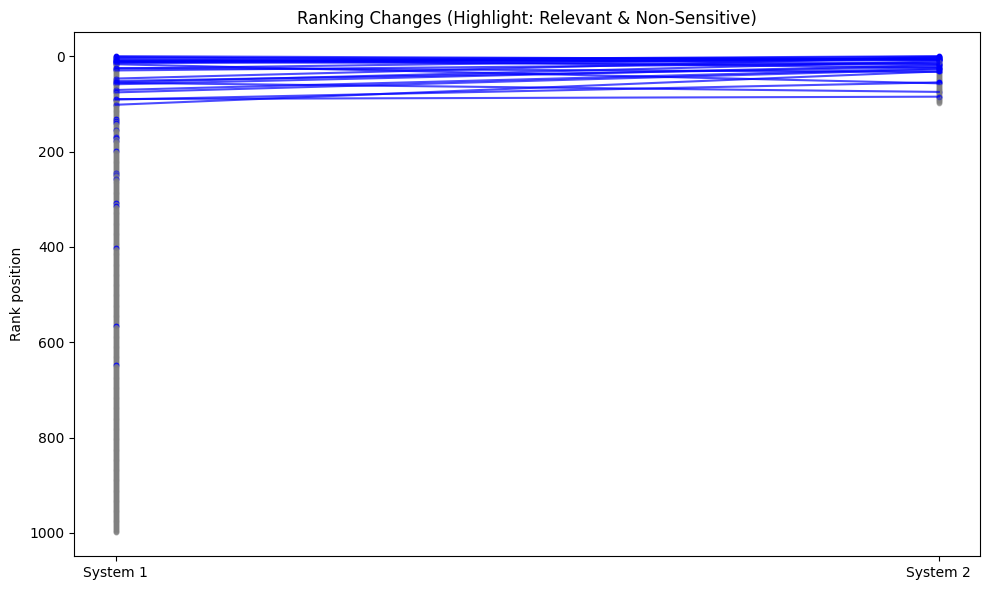

In [22]:
# Identify which rows are relevant & non-sensitive
merged['highlight'] = (merged['label'] > 0) & (merged['sensitivity'] == 0)

# Plot
plt.figure(figsize=(10, 6))

# Plot all points: system 1 and system 2
for _, row in tqdm(merged.iterrows(), total = len(merged), desc = "plotting"):
    color = 'blue' if row['highlight'] else 'gray'
    alpha = 1.0 if row['highlight'] else 0.3

    plt.scatter(0, row['rank_1'], color=color, alpha=alpha, s=10)
    plt.scatter(1, row['rank_2'], color=color, alpha=alpha, s=10)

    # Draw line only if highlight
    if row['highlight']:
        plt.plot([0, 1], [row['rank_1'], row['rank_2']], color=color, alpha=0.7)

plt.xticks([0, 1], ['System 1', 'System 2'])
plt.gca().invert_yaxis()
plt.ylabel("Rank position")
plt.title("Ranking Changes (Highlight: Relevant & Non-Sensitive)")
plt.tight_layout()
plt.show()